# 13章 待ち行列と通信品質

本章では、スイッチやルータなどの通信機器におけるパケットの転送順序について扱います。前章までは複数の通信装置間で連携するためのプロトコルや手順を扱ってきましたが、ここで一度、通信装置内部の動作の理解に移行します。一つの通信ノードや回線を多数のアプリケーションが共用するとき、リアルタイム性の高い通信を優先させたり、公平に扱ったりしたい，というケースがあります。そういったとき、通信機器内のメモリに保存されたパケットをどのような順番で読み出して送出するか、が重要です。本章では、こうした仕組みを扱うための「待ち行列」という考え方と、遅延などの通信品質について、実装しながら学んでいきます。

## 待ち行列

### 待ち行列とは

「待ち行列」とは、お店の行列と同じで「到着するデータ（パケット）をどのように待たせるか」を抽象的なモデルで表したものです。本章で急にこのような抽象的な話題が出てきたのは、ネットワークリソースの有限性が重要な問題になるからです。通信パケットを処理するためには、ネットワークの帯域などのリソースを、少しの時間だけ占有して使用する必要があります。一般的にリソースが潤沢にあるに越したことはないのですが、そのためには非常に大きなコストがかかります。したがって、制限のあるリソースを上手に使うことは非常に重要な問題です。

たくさんのユーザやアプリケーションからの要求を効率的に処理することは古典的かつ重要な問題です。例えば、リアルタイム系サービスでは応答時間を非常に短くする必要があるなど、アプリケーションごとに異なる要求条件があるため、うまくパケットを待たせたる（あるいは待たせない）必要があるのです。

### スケジューリングとは

待ち行列に対して、「データ（パケット）をどのようにさばくか」を「スケジューリング」と呼びます。通信ネットワークでは、電話など高いリアルタイム性が要求される通信を、Webブラウジングなどより優先して転送する、といったスケジューリングが一般的に行われます。

スケジューリングの概念自体はとても身近なもので、私たちの普段の生活でも日常的に利用されています。例えば、病院における外来の受付と患者の順番待ちを考えてみると、基本的には来院順に診察室に呼ばれることが多いと思います。これは、私たちの目には見えない（仮想的な）待ち行列が存在しており、並び順に従ってサービスが提供されていることに等しいと言えます。ただし、あらかじめ来院時間の指定された予約者の存在や、緊急患者の優先などにより、順番待ちの行列に対する割り込みが発生することがあります。これはすなわち、病院側が仮想的な待ち行列を複数準備しており、順番をコントロール（＝スケジューリング）している、とも解釈できます。

コンピュータシステムでよくある目標としては、遅延（待ち時間）を小さくする、公平性を高める（異なるユーザやアプリケーションのデータを平等に処理する）といったものがあります。また、アプリケーションによっては遅延などに具体的な要求が設定されることがあります。例えば電話の通信では、一般的に片道150ms程度の遅延までであれば気にならないことが多いとされ、この値を要求条件に設定したとします。システム全体としてこれを満たすために、ある装置における遅延を例えば10$\mu$s以下にする、といった要求が設定された場合、このブレークダウンされた条件を満たすようにスケジューリングを行うことが目標となります。

### キューイングと待ち行列モデル

待ち行列の作り方とスケジューリングの方法は、非常に密接に関わります。待ち行列は英語でキュー（Queue）と呼ばれます。新たな顧客（患者やデータ、プロセス）が到着して待ち行列に並ぶ、すなわちキューに入力することをキューイングと呼びます。

待ち行列の作り方について、イメージしやすいのは、窓口やレジの並び方（キューイング）とさばき方（スケジューリング）の関係です。まず窓口が複数あったとき、窓口ごとに待ち行列を作るか、全体で1つの待ち行列を作る（いわゆるフォーク並び）か、といった方法が考えられます。前者であれば窓口ごとに独立したスケジューリングを行えば十分ですが、後者の場合には列の先頭の人を空いた窓口へ適切に案内していく、といったスケジューリングが必要になります。

このような待ち行列とスケジューリングについては、「待ち行列モデル」と呼ばれるモデルを用いて、抽象化して考えることが一般的に行われます。最も単純な待ち行列モデルの概念図を以下に示します。これは、1個のキューと1個のスケジューラからなるモデルです。キューに入れられたデータは、何らかの順番で（一般的には先頭から順番に）スケジューラによって読み出され、キューから出力されます。このとき、データを入れることをエンキュー、データを出すことをデキューと呼びます。待ち行列については理論的な解析が古くから行われており、平均待ち時間などを理論的に求めることができます。ここでは、シミュレーションによって挙動をみていきます。


## FIFO (First In First Out)

### 実装の方針

本章では、まずシンプルな待ち行列とスケジューリングのシミュレーションを行い、その挙動を理解します。その上で、前章までに実装してきたシミュレータの`Link`クラスに対する実装を行います。これは、前章までに扱ってきたようなプロトコルでは動作順序などが重要であるのに対して、本章で扱う内容は理屈や数理的な色が強いため、まずはシンプルなコードで学習した方が分かり易いためです。また、ここでは直感的に分かり易いよう、シンプルさを最優先した実装を行います。

### FIFOキュー

FIFOとは、待ち行列とスケジューリングに関する最も単純なモデルです。「First In First Out」の名前の通り「先に入ったものを先に出す」方法です。キューに到着したデータは、行列の最後尾に追加されます。そしてデータを読み出すスケジューラは、常に行列の先頭を読み出していきます。その結果、データは到着した順番で出ていくこととなります。FIFOはその単純さゆえ、処理負荷が非常に低いため高速処理が可能です．また低価格な機器にも実装しやすいという利点があります。一方で、きめ細かな順番の制御などはまったくできません。

まず、非常に簡単なシミュレーションを実行して、FIFOキューの雰囲気をつかんでみましょう。以下の例では、Pythonの標準ライブラリcollectionsモジュールのdeque型をFIFOキューとして用いています。deque型は「両端キュー」などとも呼ばれ、先頭と末尾のどちらからでもデータの追加や取り出しを行うことができます。

ここではまずFIFOキューを1つ準備し、これに対して、単位時間（簡単のため1秒とします）あたり1つずつデータを入力した後で、単位時間あたり1つずつデータを出力して (読み出して) いきます。入力するデータのサイズが100, 200, 300, 400, 500 [byte] の順であるとき、キュー長 (キューに入っているデータ量であり、キューサイズなどとも呼ぶ) の変化を観測してみましょう。データの入出力に応じてキューサイズが増減することが分かります。


deque([100])
deque([100, 200])
deque([100, 200, 300])
deque([100, 200, 300, 400])
deque([100, 200, 300, 400, 500])
deque([200, 300, 400, 500])
deque([300, 400, 500])
deque([400, 500])
deque([500])
deque([])


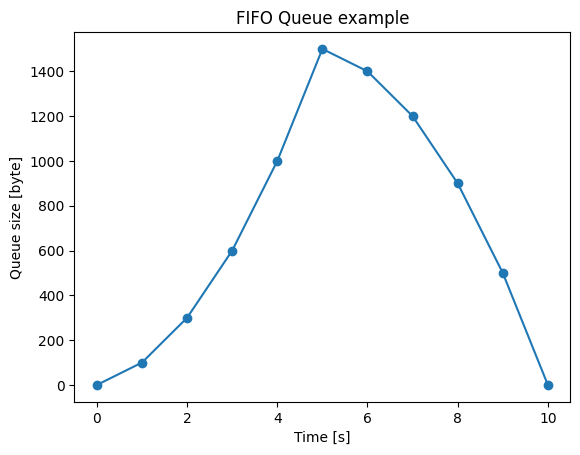

In [1]:
from collections import deque
import matplotlib.pyplot as plt

# dequeをFIFOキューとして用いる
q = deque()

# 100, 200, 300, 400, 500 [byte] のデータを準備
data = [100, 200, 300, 400, 500]

t = 0 # 時刻
T = [t]
L = [sum(q)] # キューサイズ

# qに対してデータを入力 (enque)
for i in range(len(data)):
  t += 1
  q.append(data[i])
  print(q) # qの中身を確認
  T.append(t)
  L.append(sum(q))

# qからデータを出力 (deque)
while len(q) > 0:
  t += 1
  q.popleft()
  print(q) # qの中身を確認
  T.append(t)
  L.append(sum(q))

# グラフを作成
plt.plot(T, L, marker="o")
plt.title("FIFO Queue example")
plt.xlabel("Time [s]")
plt.ylabel("Queue size [byte]")
plt.show()


### FIFOキュー出力時のデータサイズの考慮

ただし実際のシステムでは、データの出力に要する時間はデータサイズに依存するのが一般的です（つまり，大きなデータほど出力に時間がかかるのが普通です）。今度は、FIFOキューに対して、先ほどと同様のタイミングで100, 200, 300, 400, 500 [byte] のデータを入力した後で、データサイズに応じた時間でデータを出力していきます。つまり、出力速度 R、データサイズ B とおくとき、このデータの出力に要する時間は BRです。

このとき、キューの出力速度は一定であることから、データが連続で出力される場合にはキューサイズは直線的に減少する、ということが分かります。ちなみに、今回は1つのデータの入出力が完了した時点での時刻とキューサイズをプロットし、単純に繋いでいったために直線的なグラフになりましたが、メモリの使い方などを考慮して階段状のグラフとすることも考えられます。


deque([100])
deque([100, 200])
deque([100, 200, 300])
deque([100, 200, 300, 400])
deque([100, 200, 300, 400, 500])
deque([200, 300, 400, 500])
deque([300, 400, 500])
deque([400, 500])
deque([500])
deque([])


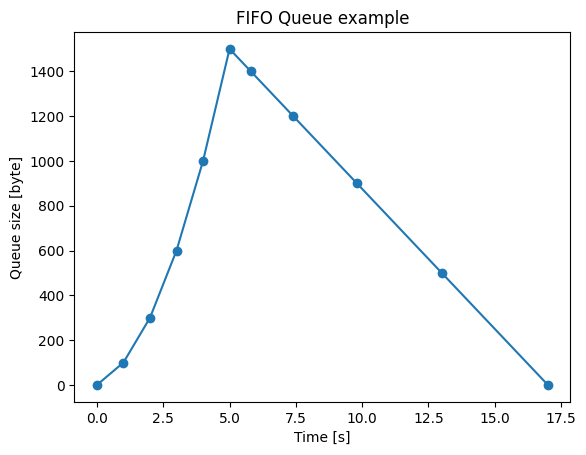

In [2]:
from collections import deque
import matplotlib.pyplot as plt

# dequeをFIFOキューとして用いる
q = deque()

# 100, 200, 300, 400, 500 [byte] のデータを準備
data = [100, 200, 300, 400, 500]

# 出力速度 = 1000 [bps] とする
rate = 1000 / 8 # byte per secondで計算

t = 0.0 # 時刻
T = [t]
L = [sum(q)] # キューサイズ

#  qに対してデータを入力 (enque)
for i in range(len(data)):
  t += 1
  q.append(data[i])
  print(q) # qの中身を確認
  T.append(t)
  L.append(sum(q))

# qからデータを出力 (deque)
while len(q) > 0:
  t += q.popleft() / rate # B / R
  print(q) # qの中身を確認
  T.append(t)
  L.append(sum(q))

# グラフを作成
plt.plot(T, L, marker="o")
plt.title("FIFO Queue example")
plt.xlabel("Time [s]")
plt.ylabel("Queue size [byte]")
plt.show()


### FIFOキューへの入出力のパラレル化

ここまでの例では、キューへのデータ入力が完了した後で出力を開始していました。しかしながら、実際にはキューへの入力と出力は並行して行われる点に注意が必要です。そこで、以下では入出力をパラレルで行うシミュレーションを行ってみましょう。なお簡単のため、データの入力速度は非常に速く、データサイズによらず入力に要する時間は無視できるものとします。

シミュレーション開始から30秒間はランダムにデータが入力しつつ、同時に一定速度でデータが出力されていくので、キューサイズは増えたり減ったりしています。30秒を過ぎるとデータ入力が止まるので、あとはデータがなくなるまで一定速度での出力が続いていきます。このようにして、最も基本的なFIFOキューを簡単にシミュレーションすることができました。


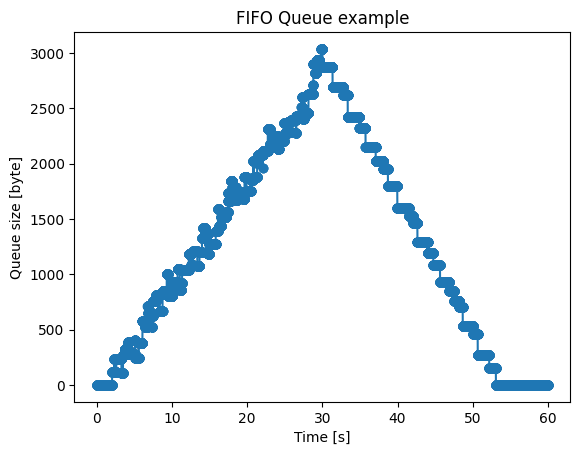

In [3]:
from collections import deque
import matplotlib.pyplot as plt
import random

# dequeをFIFOキューとして用いる
q = deque()

# 出力速度 = 1000 [bps] とする
rate = 1000 / 8 # byte per secondで計算

T = [0]
L = [sum(q)] # キューサイズ
end_time = 60.0 # シミュレーション時間

last_enque = 0 # 入力時刻
deque_end = 0 # 出力終了時刻
interval = random.random() # 次の入力までの時間間隔

t = 0
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  if t - last_enque > interval and t < end_time / 2: # 入力有無の判定，ただしシミュレーション後半は入力なしとする
    q.append(random.randint(50,200)) # 50～200 [byte] のランダムサイズ
    interval = random.random() # 0～1 [s] のランダム間隔
    last_enque = t # 入力時刻をアップデート
  if t > deque_end and len(q) > 0: # 出力終了判定
    deque_end = t + q.popleft() / rate # 出力終了時刻を算出
  T.append(t)
  L.append(sum(q))

# グラフを作成
plt.plot(T, L, marker="o")
plt.title("FIFO Queue example")
plt.xlabel("Time [s]")
plt.ylabel("Queue size [byte]")
plt.show()

### FIFOキューの入力速度と出力速度の関係

キューからデータが出力される速度とはすなわち、システムの処理能力を表します。出力速度は、計算能力や通信速度などシステムリソースから定まるため、通常は短時間で増減するようなものではありません。FIFOキューにおいて、待ち行列が伸びる = キューにデータが蓄積することは、待ち時間の増加を意味します。そして、待ち行列が伸びるかどうかは、入力がどのくらいあるか？によって定まります。

まず、キューからの出力速度を1Mbpsとします。先ほどまでと同様、時刻 t=0 のときキュー長 q(t)=0 であるとします。このキューに対して、ランダムな間隔でランダムなサイズのデータが入力するものとします。入力するデータのサイズは平均1000バイト、標準偏差100バイトの正規分布で表されるとします。なおデータの入力速度は非常に速く、データサイズによらず入力に要する時間は無視できるものとします。

まずはデータの入力間隔が平均10ms、標準偏差2msの正規分布とします。キュー長 q(t) の推移を確認してみましょう。結果としては、キューサイズはほぼ常に0～1000byte程度に抑えられています。これは、到着したデータはキューイングされた後、すぐに出力されていくため、キュー内にデータが蓄積しないことを表しています。


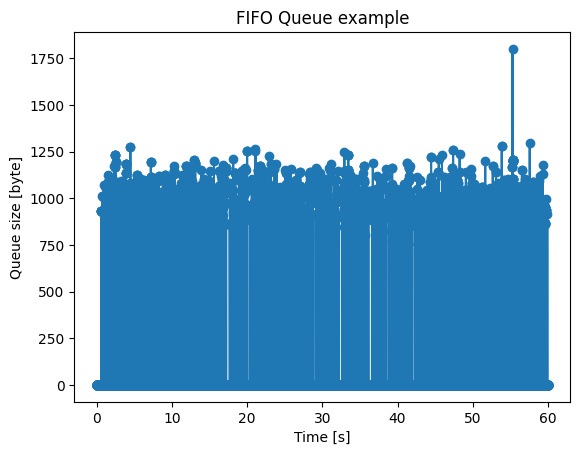

In [4]:
from collections import deque
import matplotlib.pyplot as plt
import random

# dequeをFIFOキューとして用いる
q = deque()

# 出力速度 = 1000000 [bps] とする
rate = 1000000 / 8 # byte per secondで計算

T = [0]
L = [sum(q)] # キューサイズ
end_time = 60.0 # シミュレーション時間

# データサイズ
s_mu = 1000 # 平均 [byte]
s_sigma = 100 # 標準偏差 [byte]

# データ到着間隔
i_mu = 0.01 # 平均 [s]
i_sigma = 0.002 # 標準偏差 [s]

last_enque = 0 # 入力時刻
deque_end = 0 # 出力終了時刻
interval = random.random() # 次の入力までの時間間隔

t = 0
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  if t - last_enque > interval: # 入力有無の判定
    q.append(random.gauss(s_mu, s_sigma)) # データサイズは平均mu，標準偏差sigmaの正規分布
    interval = random.gauss(i_mu, i_sigma) # データ到着間隔は平均mu，標準偏差sigmaの正規分布
    last_enque = t # 入力時刻をアップデート
  if t > deque_end and len(q) > 0: # 出力終了判定
    deque_end = t + q.popleft() / rate # 出力終了時刻を算出
  T.append(t)
  L.append(sum(q))

# グラフを作成
plt.plot(T, L, marker="o")
plt.title("FIFO Queue example")
plt.xlabel("Time [s]")
plt.ylabel("Queue size [byte]")
plt.show()

次に、データ入力間隔が短くなり、平均7ms、標準偏差1msの正規分布となった場合について、同様にシミュレーションしてみましょう。

今度は先ほどとは一転して、キューサイズは単調に増加しています。これはつまり、入力の多さに対して出力速度が追いつかず、どんどんキューにデータが蓄積してしまうことを表しています。これでは、待ち行列での待ち時間が大きくなりすぎて、十分なサービスを提供できていないと考えられます。


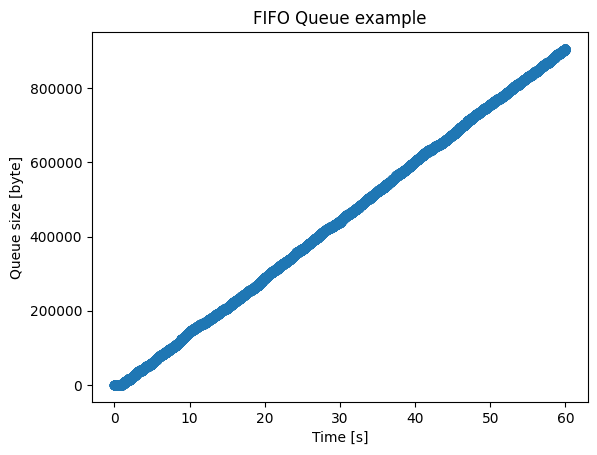

In [5]:
from collections import deque
import matplotlib.pyplot as plt
import random

# dequeをFIFOキューとして用いる
q = deque()

# 出力速度 = 1000000 [bps] とする
rate = 1000000 / 8 # byte per secondで計算

T = [0]
L = [sum(q)] # キューサイズ
end_time = 60.0 # シミュレーション時間

# データサイズ
s_mu = 1000 # 平均 [byte]
s_sigma = 100 # 標準偏差 [byte]

# データ到着間隔
i_mu = 0.007 # 平均 [s]
i_sigma = 0.001 # 標準偏差 [s]

last_enque = 0 # 入力時刻
deque_end = 0 # 出力終了時刻
interval = random.random() # 次の入力までの時間間隔

t = 0
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  if t - last_enque > interval: # 入力有無の判定
    q.append(random.gauss(s_mu, s_sigma)) # データサイズは平均mu，標準偏差sigmaの正規分布
    interval = random.gauss(i_mu, i_sigma) # データ到着間隔は平均mu，標準偏差sigmaの正規分布
    last_enque = t # 入力時刻をアップデート
  if t > deque_end and len(q) > 0: # 出力終了判定
    deque_end = t + q.popleft() / rate # 出力終了時刻を算出
  T.append(t)
  L.append(sum(q))

# グラフを作成
plt.plot(T, L, marker="o")
plt.title("FIFO Queue example")
plt.xlabel("Time [s]")
plt.ylabel("Queue size [byte]")
plt.show()

## ラウンドロビン

### ラウンドロビンの概要

次は、もう少し複雑な順番の制御が可能な待ち行列の作り方について学んでいきます。FIFOキューを複数並べた構成を考えます。これは窓口の例で言えば、1つの窓口に対して複数の列を作る方法です。実際にはメモリ内の保存領域を複数用意するようなイメージで実装されます。到着したデータは、何らかの条件でいずれかのキューに入力されます。この条件はシステムに応じて決められますが、例えばプロセスの種類ごとに振り分けたり、ユーザごとに振り分ける、といったことがあります。

ラウンドロビンは、このような構成において代表的なアルゴリズムで、各キューから単純に「順番こ」にデータを読み出します。各キューの中でのデータ送信順序は、通常FIFOが用いられます。ラウンドロビンは単純なアルゴリズムなので実装がしやすく、また各キューに対して送信機会が公平に割り当てられます。ただし、各キューに振り分けられるデータ量や平均データサイズが異なるなど、何らかの不均衡が存在する場合には、スループットは必ずしも公平化されるとは限らないという課題もあります。

### ラウンドロビンのシミュレーション

さて、FIFOキューをいくつか使って、ラウンドロビンのシミュレーションを実行してみましょう。ここではFIFOキューを4個作り、それぞれキュー0，キュー1，キュー2，キュー3と呼ぶこととします。先ほどと同様に、出力速度を1Mbpsとします。上図の通り、並ぶ列は増えましたが、出口の数は変わっていないことに注意します。

今回は、キュー i のデータを出力したら、次はキュー i+1 のデータを出力することとします。ただし i=3 の場合には、次はキュー 0 となります。つまり1つの窓口に対して4つの行列があり、列0→列1→列2→列3→列0→・・といった順番で呼び出されることになります。これらのキューに対するデータの入力間隔が、それぞれ平均30ms、標準偏差2msの正規分布で表されるとします。またデータ入力間隔以外の条件は、先ほどと同じとします。このとき、4つの待ち行列それぞれの長さの推移は以下のようになります。


Text(0, 0.5, 'Queue size [byte]')

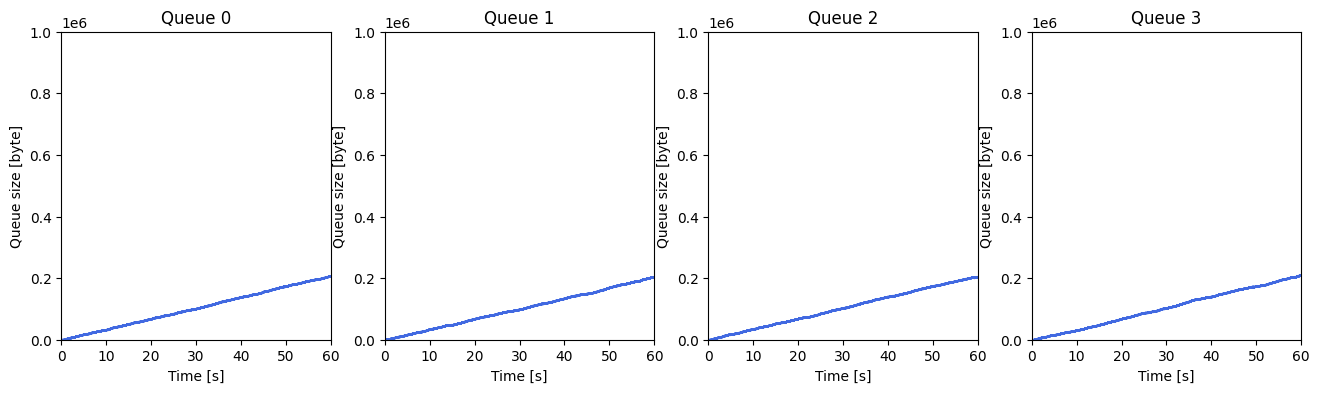

In [6]:
from collections import deque
import matplotlib.pyplot as plt
import random

# FIFOキューを4つ入れたリストを作成
N = 4
queues = []
for i in range(N):
  queues.append(deque())

# 出力速度 = 1000000 [bps] とする
rate = 1000000 / 8 # byte per secondで計算

T = [0]
L = [] # キューサイズ
for i in range(N):
  l = [0]
  L.append(l)
end_time = 60.0 # シミュレーション時間

# データサイズ
s_mu = 1000 # 平均 [byte]
s_sigma = 100 # 標準偏差 [byte]

# データ到着間隔
i_mu = 0.03 # 平均 [s]
i_sigma = 0.002 # 標準偏差 [s]

last_enque = [0] * N # 入力時刻
deque_end = 0 # 出力終了時刻
interval = [] # 次の入力までの時間間隔
for i in range(N):
  interval.append(random.random())

t = 0
next = 0 # 次に出力するキューを表すインデックス
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  for i in range(N): # キューごとに独立にデータ入力処理
    if t - last_enque[i] > interval[i]: # 入力有無の判定
      queues[i].append(random.gauss(s_mu, s_sigma)) # データサイズは平均mu，標準偏差sigmaの正規分布
      interval[i] = random.gauss(i_mu, i_sigma) # データ到着間隔は平均mu，標準偏差sigmaの正規分布
      last_enque[i] = t # 入力時刻をアップデート
  if t > deque_end and sum(sum(x) for x in queues) > 0: # 出力終了判定
    while len(queues[next]) == 0: # もしデータがなければ次へ回す
      next = (next + 1) % 4 # 0 -> 1 -> 2 -> 3 -> 0 -> ...
    deque_end = t + queues[next].popleft() / rate # 出力終了時刻を算出
    next = (next + 1) % 4 # 0 -> 1 -> 2 -> 3 -> 0 -> ...
  T.append(t)
  for i in range(N):
    L[i].append(sum(queues[i]))

# グラフを作成
max = 1000000
fig = plt.figure(figsize=(16.0, 4.0))
ax0 = fig.add_subplot(1, 4, 1)
ax0.plot(T, L[0], color="royalblue")
ax0.set_title("Queue 0")
ax0.set_xlim([0, end_time])
ax0.set_ylim([0, max])
ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Queue size [byte]")

ax1 = fig.add_subplot(1, 4, 2)
ax1.plot(T, L[1], color="royalblue")
ax1.set_title("Queue 1")
ax1.set_xlim([0, end_time])
ax1.set_ylim([0, max])
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Queue size [byte]")

ax2 = fig.add_subplot(1, 4, 3)
ax2.plot(T, L[2], color="royalblue")
ax2.set_title("Queue 2")
ax2.set_xlim([0, end_time])
ax2.set_ylim([0, max])
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Queue size [byte]")

ax3 = fig.add_subplot(1, 4, 4)
ax3.plot(T, L[3], color="royalblue")
ax3.set_title("Queue 3")
ax3.set_xlim([0, end_time])
ax3.set_ylim([0, max])
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Queue size [byte]")


結果としては、すべてのキューについて、それぞれ同じようにデータが少しずつ蓄積していくという結果になりました。1Mbpsの出力速度を、4つの待ち行列で4等分して使う、という形になるので、キューあたりの見かけ上の出力速度は約0.25Mbpsになります。

さて、今の条件では4つのFIFOキューに入力するデータ量の期待値はまったく同じでした。では、各FIFOキューに入力するデータ量が異なる場合には、どのようになるでしょうか。データ入力間隔以外の条件は先ほどまでと同様として、各キューのデータ入力間隔を以下のように設定します。

- キュー0：平均10ms，標準偏差2msの正規分布
- キュー1：平均20ms，標準偏差2msの正規分布
- キュー2：平均30ms，標準偏差2msの正規分布
- キュー3：平均40ms，標準偏差2msの正規分布

このとき、4つの待ち行列それぞれの長さの推移は、以下のようになります。


Text(0, 0.5, 'Queue size [byte]')

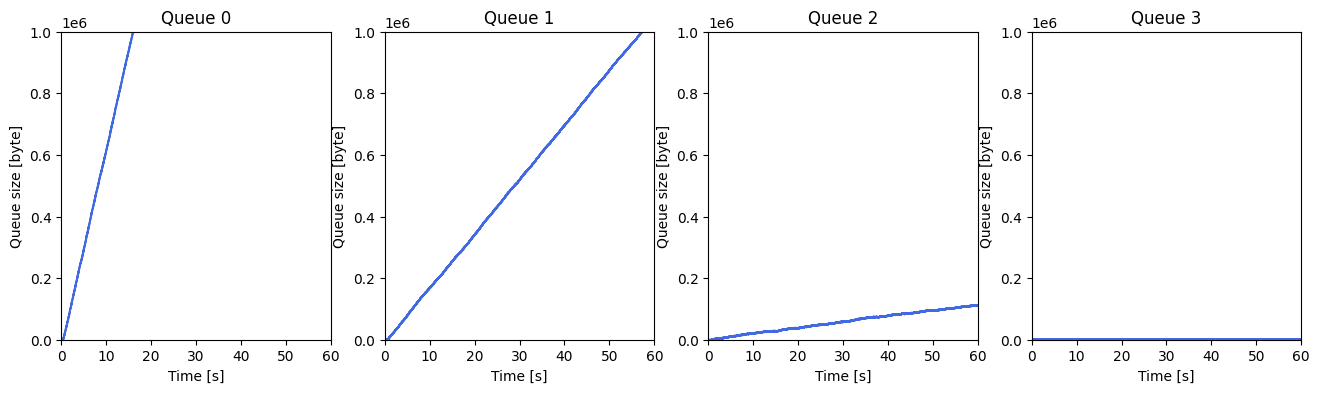

In [7]:
from collections import deque
import matplotlib.pyplot as plt
import random

# FIFOキューを4つ入れたリストを作成
N = 4
queues = []
for i in range(N):
  queues.append(deque())

# 出力速度 = 1000000 [bps] とする
rate = 1000000 / 8 # byte per secondで計算

T = [0]
L = [] # キューサイズ
for i in range(N):
  l = [0]
  L.append(l)
end_time = 60.0 # シミュレーション時間

# データサイズ
s_mu = 1000 # 平均 [byte]
s_sigma = 100 # 標準偏差 [byte]

# データ到着間隔
i_mu = [0.01, 0.02, 0.03, 0.04] # 平均
i_sigma = [0.002, 0.002, 0.002, 0.002] # 標準偏差 [s]

last_enque = [0] * N # 入力時刻
deque_end = 0 # 出力終了時刻
interval = [] # 次の入力までの時間間隔
for i in range(N):
  interval.append(random.random())

t = 0
next = 0 # 次に出力するキューを表すインデックス
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  for i in range(N): # キューごとに独立にデータ入力処理
    if t - last_enque[i] > interval[i]: # 入力有無の判定
      queues[i].append(random.gauss(s_mu, s_sigma)) # データサイズは平均mu，標準偏差sigmaの正規分布
      interval[i] = random.gauss(i_mu[i], i_sigma[i]) # データ到着間隔は平均mu，標準偏差sigmaの正規分布
      last_enque[i] = t # 入力時刻をアップデート
  if t > deque_end and sum(sum(x) for x in queues) > 0: # 出力終了判定
    while len(queues[next]) == 0: # もしデータがなければ次へ回す
      next = (next + 1) % 4 # 0 -> 1 -> 2 -> 3 -> 0 -> ...
    deque_end = t + queues[next].popleft() / rate # 出力終了時刻を算出
    next = (next + 1) % 4 # 0 -> 1 -> 2 -> 3 -> 0 -> ...
  T.append(t)
  for i in range(N):
    L[i].append(sum(queues[i]))

# グラフを作成
max = 1000000
fig = plt.figure(figsize=(16.0, 4.0))
ax0 = fig.add_subplot(1, 4, 1)
ax0.plot(T, L[0], color="royalblue")
ax0.set_title("Queue 0")
ax0.set_xlim([0, end_time])
ax0.set_ylim([0, max])
ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Queue size [byte]")

ax1 = fig.add_subplot(1, 4, 2)
ax1.plot(T, L[1], color="royalblue")
ax1.set_title("Queue 1")
ax1.set_xlim([0, end_time])
ax1.set_ylim([0, max])
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Queue size [byte]")

ax2 = fig.add_subplot(1, 4, 3)
ax2.plot(T, L[2], color="royalblue")
ax2.set_title("Queue 2")
ax2.set_xlim([0, end_time])
ax2.set_ylim([0, max])
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Queue size [byte]")

ax3 = fig.add_subplot(1, 4, 4)
ax3.plot(T, L[3], color="royalblue")
ax3.set_title("Queue 3")
ax3.set_xlim([0, end_time])
ax3.set_ylim([0, max])
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Queue size [byte]")


今度は、それぞれの待ち行列でまったく挙動が違うことが分かります。キュー0, 1に対しては、どんどんデータが蓄積していく一方で、キュー2では蓄積量は少なめにとどまり、キュー3に至っては待ち行列のサイズはほぼずっとゼロです。この結果は、各キューに対する入力データ量の違いをそのまま反映しています。つまり、キューあたりの見かけ上の出力速度は、合計出力速度を4等分した約0.25Mbpsになるため、データ入力頻度が高いキューほど、データの蓄積速度が速くなるのです。


## 優先制御

### 優先制御の概要

ここまでの事例では、データの間に優劣はないことを前提にしていました。次は、複数の待ち行列を用いたときに、各キューに明示的に優先度を定めて読み出し順序を決める優先制御（PQ; priority queuing）について学びます。優先制御は、例えばテーマパークにおけるファストパスの列と一般の列、空港でのビジネスクラスの列とエコノミークラスの列など、日常生活の中でも実際に使われている考え方です。

通信ネットワークでよく行われるのは、電話などのリアルタイム性が要求されるパケットを高優先として、Webブラウジングなど遅延が少し大きくても問題ないパケットを低優先（ベストエフォートと呼ばれます）で転送する、という優先制御です。この場合、高優先パケット用のキューと低優先パケット用のキューを用意して、高優先キューにパケットが存在する限り、常に高優先キューからパケットを読み出し続ける、ということを行います。

### 優先制御のシミュレーション

ラウンドロビンの最初のシミュレーションを行ったときと同様の条件を設定します。そして，今度はキューの読み出しをラウンドロビンではなく、完全優先制御とし、より優先度の高いキューにデータがあるときには、必ず優先的にデータを出力するようにします。各キューの優先度を、 0>1>2>3 （ 0 が最も優先度が高い）と設定します。

このとき、4つの待ち行列それぞれの長さの推移は、以下のようになります。キュー0 > キュー1 > キュー2 > キュー3という順序で優先的に出力を行った結果として、キュー0, 1, 2のデータ量は常にほぼゼロとなりました。一方でキュー3については、出力しきれない分のデータが徐々に蓄積していき、行列の長さが単調に増加しています。


Text(0, 0.5, 'Queue size [byte]')

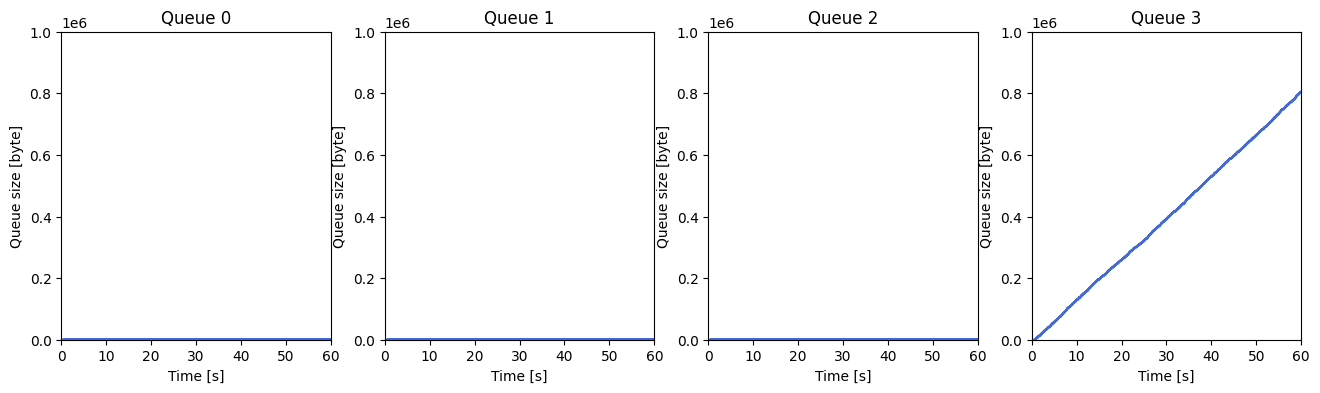

In [8]:
from collections import deque
import matplotlib.pyplot as plt
import random

# FIFOキューを4つ入れたリストを作成
N = 4
queues = []
for i in range(N):
  queues.append(deque())

# 出力速度 = 1000000 [bps] とする
rate = 1000000 / 8 # byte per secondで計算

T = [0]
L = [] # キューサイズ
for i in range(N):
  l = [0]
  L.append(l)
end_time = 60.0 # シミュレーション時間

# データサイズ
s_mu = 1000 # 平均 [byte]
s_sigma = 100 # 標準偏差 [byte]

# データ到着間隔
i_mu = 0.03 # 平均 [s]
i_sigma = 0.002 # 標準偏差 [s]

last_enque = [0] * N # 入力時刻
deque_end = 0 # 出力終了時刻
interval = [] # 次の入力までの時間間隔
for i in range(N):
  interval.append(random.random())

t = 0
next = 0 # 次に出力するキューを表すインデックス
while t < end_time: # ループで時間を進める
  t += 0.001 # 0.001秒ずつ進める (精度は低い)
  for i in range(N): # キューごとに独立にデータ入力処理
    if t - last_enque[i] > interval[i]: # 入力有無の判定
      queues[i].append(random.gauss(s_mu, s_sigma)) # データサイズは平均mu，標準偏差sigmaの正規分布
      interval[i] = random.gauss(i_mu, i_sigma) # データ到着間隔は平均mu，標準偏差sigmaの正規分布
      last_enque[i] = t # 入力時刻をアップデート
  if t > deque_end and sum(sum(x) for x in queues) > 0: # 出力終了判定
    if len(queues[0]) > 0:
      next = 0
    elif len(queues[1]) > 0:
      next = 1
    elif len(queues[2]) > 0:
      next = 2
    else:
      next = 3
    deque_end = t + queues[next].popleft() / rate # 出力終了時刻を算出
  T.append(t)
  for i in range(N):
    L[i].append(sum(queues[i]))

# グラフを作成
max = 1000000
fig = plt.figure(figsize=(16.0, 4.0))
ax0 = fig.add_subplot(1, 4, 1)
ax0.plot(T, L[0], color="royalblue")
ax0.set_title("Queue 0")
ax0.set_xlim([0, end_time])
ax0.set_ylim([0, max])
ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Queue size [byte]")

ax1 = fig.add_subplot(1, 4, 2)
ax1.plot(T, L[1], color="royalblue")
ax1.set_title("Queue 1")
ax1.set_xlim([0, end_time])
ax1.set_ylim([0, max])
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Queue size [byte]")

ax2 = fig.add_subplot(1, 4, 3)
ax2.plot(T, L[2], color="royalblue")
ax2.set_title("Queue 2")
ax2.set_xlim([0, end_time])
ax2.set_ylim([0, max])
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Queue size [byte]")

ax3 = fig.add_subplot(1, 4, 4)
ax3.plot(T, L[3], color="royalblue")
ax3.set_title("Queue 3")
ax3.set_xlim([0, end_time])
ax3.set_ylim([0, max])
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Queue size [byte]")


### `Packet` クラスのアップデート

#### DSCPフィールドの追加

`Packet`クラスのIPヘッダに対して、優先度を表すDSCPフィールドを定義します。IPヘッダのToSフィールドのうち6ビットを用いるDSCP（Differentiated Services Code Point）というフィールドを、以下のように実装します。

```
class Packet:
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, ttl, fragment_flags, fragment_offset, header_size, payload_size, network_event_scheduler, dscp=0):
        self.network_event_scheduler = network_event_scheduler
        self.id = str(uuid.uuid4())
        # MACヘッダとIPヘッダを分割して管理
        self.mac_header = {
            "source_mac": source_mac,
            "destination_mac": destination_mac
        }
        self.ip_header = {
            "source_ip": source_ip,
            "destination_ip": destination_ip,
            "ttl": ttl,
            "fragment_flags": fragment_flags,
            "fragment_offset": fragment_offset,
            "dscp": dscp  # DSCPフィールド
        }
```

DSCPフィールドは6ビットのため、64段階の優先度を表現することができる一方で、従来のIP Precedenceでは、ToSフィールド中の3ビットを用いて8通りの優先度を設定します。細かい点ですが、この互換性を保つためにDSCPの上位3ビットのみを用いた場合にも8クラスを識別できるように運用されることがあります。またシミュレーション上は8クラス程度のほうが扱いやすいので、今回は以下のように実装します。

```
    def get_priority(self):
        # Map DSCP values to priority levels (0-7, with 7 being the highest priority)
        dscp = self.ip_header["dscp"]
        if dscp >= 56:  # Network Control
            return 7
        elif dscp >= 48:  # Expedited Forwarding
            return 6
        elif dscp >= 40:  # Assured Forwarding 4
            return 5
        elif dscp >= 32:  # Assured Forwarding 3
            return 4
        elif dscp >= 24:  # Assured Forwarding 2
            return 3
        elif dscp >= 16:  # Assured Forwarding 1
            return 2
        elif dscp > 8:  # Class Selector
            return 1
        else:  # Best Effort
            return 0
```

また`ARPPacket`などの制御用パケットについては、DSCP=56に設定し、最高の優先度で扱われるようにアップデートします。

```
class ARPPacket(Packet):
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, operation, network_event_scheduler):
        super().__init__(
            source_mac=source_mac,
            destination_mac=destination_mac,
            source_ip=source_ip,
            destination_ip=destination_ip,
            ttl=1, fragment_flags={}, fragment_offset=0, # ダミーのTTLとフラグメント情報
            dscp=56,
            header_size=28,  # ARPヘッダの標準的なサイズ
            payload_size=28,  # ARPパケットのペイロードサイズ
            network_event_scheduler=network_event_scheduler
        )
```

### `Link` クラスのアップデート

#### 優先度キューの定義

以前はリンクの双方向に1つずつだったキューを、優先度付きキューにするためリストにします。また、各キューからの出力状況を管理するため、転送中か否かを表すフラグを定義しておきます。

```
class Link:
    def __init__(self, node_x, node_y, bandwidth, delay, loss_rate, network_event_scheduler):

        # 優先度付きキューの初期化
        self.priority_queues_xy = defaultdict(list)
        self.priority_queues_yx = defaultdict(list)

        # 転送中フラグの初期化
        self.is_transferring_xy = False
        self.is_transferring_yx = False
```

#### キューへの入力

キューへの入力を担う`enqueue_packet`をアップデートします。パケットから優先度を取得して、対応するキューへと格納します。このとき、キューにはheapqというPythonの標準ライブラリが使われています。キューに新しくパケットが追加された場合、そのキューがまだ空だった、つまり最初のパケットが追加された場合に限り、転送処理が呼び出されます。

```
def enqueue_packet(self, packet, from_node):
    # パケットの優先度を取得
    priority = packet.get_priority()

    # パケットがどのノードから来たかによって適切なキューを選択
    if from_node == self.node_x:
        # ノードXからのパケットの場合、XY方向の優先度キューと転送フラグを使用
        queue = self.priority_queues_xy[priority]
        is_transferring = self.is_transferring_xy
    else:
        # ノードYからのパケットの場合、YX方向の優先度キューと転送フラグを使用
        queue = self.priority_queues_yx[priority]
        is_transferring = self.is_transferring_yx

    # 現在の時刻を取得し、パケットを優先度キューに追加
    # heapq.heappush を使って、パケットをキューに追加（ヒープ構造を保持）
    dequeue_time = self.network_event_scheduler.current_time
    heapq.heappush(queue, (dequeue_time, packet, from_node))

    # デバッグやモニタリングのため、パケット情報を出力（verboseモードの場合）
    if self.network_event_scheduler.link_verbose:
        print(f"{self.network_event_scheduler.current_time}, enqueue packet {packet.size} bytes, priority: {priority}")

    # キューに新しいパケットが追加され、かつ現在データを転送中でない場合
    # 次の transfer_packet イベントをスケジュール
    if len(queue) == 1 and not is_transferring:
        # 現在の時刻で transfer_packet 関数をスケジュール
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time,
            self.transfer_packet,
            from_node
        )
```

#### キューからの出力

出力を担う`transfer_packet`もアップデートします。具体的には、優先度キューに格納されたパケットを取り出し、転送元ノードから転送先ノードへパケットを送る動作を管理します。この処理は、ネットワークの帯域幅や転送遅延を考慮しつつ、パケットの優先度に基づいて実行されます。

まず、転送元ノードがどちらであるかを判定し、それに応じて対応する優先度キューと「転送中フラグ」を設定します。このフラグは、現在その方向でパケットが転送中であることを示すために使用されます。次に、優先度の高いキューから順に確認し、非空のキューを見つけてパケットを取り出します。パケットが取り出される際、転送時間を計算します。この転送時間は、パケットのサイズとネットワークの帯域幅を基に算出され、転送にかかる時間を秒単位で表しています。

その後、パケットをドロップする必要があるかを確認します。たとえば、ネットワークが混雑している場合やパケットが不適切である場合には、パケットをドロップします。この場合、到着失敗の状態が記録され、転送処理はそこで終了します。一方、パケットが正常であれば、転送先のノードを決定し、そのノードでパケットを受信するイベントをスケジュールします。スケジュールは、現在の時刻に転送遅延を加えた時点で設定されます。

さらに、現在の転送処理が完了した後、キューにまだパケットが残っている場合は、次のパケット転送処理をスケジュールします。このスケジュールは、現在のパケットが転送されるのにかかる時間を考慮した後に設定されます。一方で、キューが空の場合は、「転送中フラグ」をリセットし、その方向での転送を終了します。

```
def transfer_packet(self, from_node):
    # 転送元ノードに応じて適切なキューと転送フラグを選択
    if from_node == self.node_x:
        # ノードXから転送する場合
        priority_queues = self.priority_queues_xy
        self.is_transferring_xy = True  # 転送中フラグを設定
    else:
        # ノードYから転送する場合
        priority_queues = self.priority_queues_yx
        self.is_transferring_yx = True  # 転送中フラグを設定

    # 優先度の高い順にキューをチェックし、最初に非空のキューを処理
    for priority in sorted(priority_queues.keys(), reverse=True):  # 高い優先度から順に確認
        queue = priority_queues[priority]
        if queue:  # キューが空でなければ
            # 優先度キューから最も早く到着したパケットを取り出す
            dequeue_time, packet, _ = heapq.heappop(queue)

            # パケットの転送時間を計算（サイズ[b] × 8 / 帯域幅[bps] = 秒）
            packet_transfer_time = (packet.size * 8) / self.bandwidth

            # デバッグ出力（verboseモードの場合）
            if self.network_event_scheduler.link_verbose:
                print(f"{self.network_event_scheduler.current_time:.6f}: Packet transferred from Link {self.node_x.node_id}-{self.node_y.node_id} to {from_node.node_id}. Packet size: {packet.size} bytes, Priority: {packet.get_priority()}")

            # パケットをドロップするかどうか判定
            if self.should_drop_packet(packet):
                # パケットがドロップされた場合の処理
                if self.network_event_scheduler.link_verbose:
                    print(f"{self.network_event_scheduler.current_time:.6f}: Packet dropped at Link {self.node_x.node_id}-{self.node_y.node_id}.")
                packet.set_arrived(-1)  # 到着失敗の状態を設定
            else:
                # パケットの転送先ノードを決定し、スケジュールを設定
                next_node = self.node_x if from_node != self.node_x else self.node_y
                self.network_event_scheduler.schedule_event(
                    self.network_event_scheduler.current_time + self.delay,  # 遅延を考慮した時刻
                    next_node.receive_packet,  # 次のノードのパケット受信メソッドを指定
                    packet,  # 転送するパケット
                    self  # 現在のリンク情報
                )

            # 現在のパケット転送が完了した後に次のパケット転送をスケジュール
            if any(priority_queues.values()):  # 他のキューにパケットが残っている場合
                self.network_event_scheduler.schedule_event(
                    self.network_event_scheduler.current_time + packet_transfer_time,
                    self.transfer_packet,  # 次のパケット転送を再度実行
                    from_node  # 転送元ノード
                )
                if self.network_event_scheduler.link_verbose:
                    print(f"{self.network_event_scheduler.current_time:.6f}: Schedule next packet transfer after {packet_transfer_time} seconds")
            else:
                # キューが空の場合、転送フラグをリセット
                if from_node == self.node_x:
                    self.is_transferring_xy = False
                else:
                    self.is_transferring_yx = False

            break  # 1回の呼び出しで1つのパケットのみ処理
    else:
        # すべてのキューが空の場合、転送フラグをリセット
        if from_node == self.node_x:
            self.is_transferring_xy = False
        else:
            self.is_transferring_yx = False
```

また、`Node`クラスについてもパケット生成時にDSCP値を設定できるように修正します。
その上で、以下のようにスイッチからの出力リンクにおける優先制御をシミュレーションしてみましょう。
なお、今回は`Link`クラスそのものをアップデートしたため、すべてのリンクが優先度付きキューに対応するようになっています。
従来のリンクと分けるためには、継承などを使って異なるクラスにすればよいです。

シミュレーション結果で遅延などを確認してみると、優先度の高いパケットが先に転送されて、待たされた低優先パケットの遅延が大きくなっていることが確認できます。


fatal: destination path 'network-simulator' already exists and is not an empty directory.
0, enqueue packet 70 bytes, priority: 7
0, enqueue packet 70 bytes, priority: 7
0, enqueue packet 70 bytes, priority: 7
0, enqueue packet 70 bytes, priority: 7
0, enqueue packet 70 bytes, priority: 7
0, enqueue packet 70 bytes, priority: 7


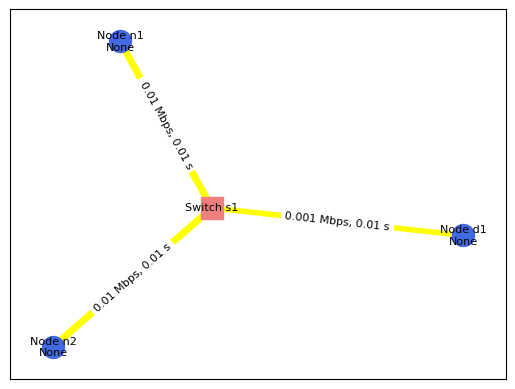

0.000000: Packet transferred from Link n1-s1 to s1. Packet size: 70 bytes, Priority: 7
0.000000, packet_transfer_time: 0.056
0.000000: Schedule next packet transfer after 0.056 seconds
0.000000: Packet transferred from Link n2-s1 to s1. Packet size: 70 bytes, Priority: 7
0.000000, packet_transfer_time: 0.056
0.000000: Schedule next packet transfer after 0.056 seconds
0.000000: Packet transferred from Link s1-d1 to s1. Packet size: 70 bytes, Priority: 7
0.000000, packet_transfer_time: 0.56
0.000000, queue is empty
0.056000: Packet transferred from Link n1-s1 to s1. Packet size: 70 bytes, Priority: 7
0.056000, packet_transfer_time: 0.056
0.056000: Schedule next packet transfer after 0.056 seconds
0.056000: Packet transferred from Link n2-s1 to s1. Packet size: 70 bytes, Priority: 7
0.056000, packet_transfer_time: 0.056
0.056000, queue is empty
0.112000: Packet transferred from Link n1-s1 to s1. Packet size: 70 bytes, Priority: 7
0.112000, packet_transfer_time: 0.056
0.112000, queue is em

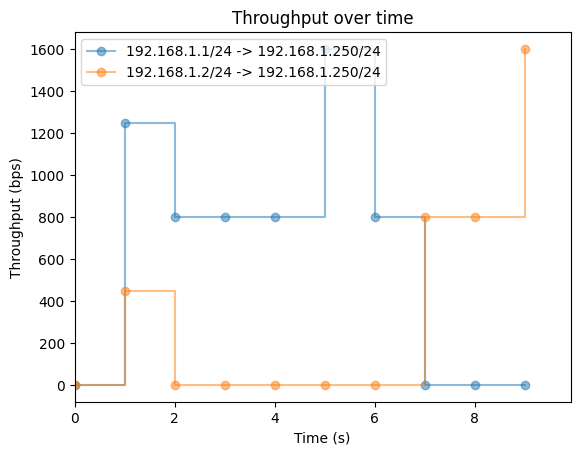

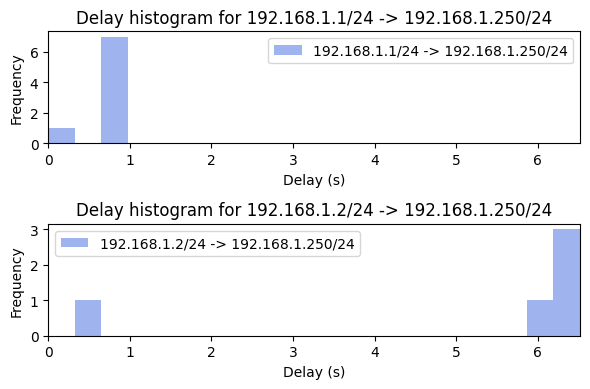

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec13a.NetworkEventScheduler import NetworkEventScheduler
from sec13a.Node import Node
from sec13a.Switch import Switch
from sec13a.Link import Link

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=False, link_verbose=True)

# ノードとルータの設定
src1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
src2 = Node(node_id="n2", ip_address="192.168.1.2/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
dst1 = Node(node_id="d1", ip_address="192.168.1.250/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(src1, switch1, bandwidth=10000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(src2, switch1, bandwidth=10000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(switch1, dst1, bandwidth=1000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
src1.start_udp_traffic(destination_url="192.168.1.250/24", bitrate=1000, start_time=1.0, duration=5.0, header_size=28, payload_size=72, dscp=16)  # 優先度高
src2.start_udp_traffic(destination_url="192.168.1.250/24", bitrate=1000, start_time=1.0, duration=5.0, header_size=28, payload_size=72, dscp=0)  # 優先度低

# イベントスケジューラを実行
nes.run_until(10.0)

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)


### 演習課題1: 優先制御の確認

#### 目的
パケットの優先度による完全優先制御の挙動の確認。

#### 課題の概要
トラフィックのDSCP値を増減させながら、パケットを送受信してみましょう。
DSCP値が高い、すなわち優先度が高いパケットが優先的に転送され、優先度が低いパケットの遅延が増大することを確認しましょう。

### 演習課題2: ラウンドロビンキューの実装

#### 目的
ラウンドロビンキューをシミュレータに実装し、公平制御について理解する。

#### 課題
完全優先制御の代わりに、ラウンドロビンでパケットを読み出して出力するキューを実装してみましょう。


## 本章のまとめ

本章では、パケットのキューイングとスケジューリングを扱いました。
待ち行列とキューおよびスケジューラの概念を学習し、シンプルなシミュレーションによって待ち時間やキュー長について学びました。
また優先制御やラウンドロビンといった基本的な手法についても確認しました。
その上で、優先度を表すフィールドをパケットに付与できるようにシミュレータをアップデートし、優先制御を実装しました。
各アプリケーションの通信品質すなわちスループットや遅延に対して、特に混雑時には優先制御が与える影響が大きいことが理解できたかと思います。
